Práctica 11:
#**Gradiente Descendiente por Lotes Estocástico y Mini Lotes**

Integrantes:


* Aguirre Lanto Victor Manuel
* Gasca Fragoso Pedro
* Guevara Badillo Areli Alejandra
* Montiel Toro Arael de Jesús
* Ramirez Lozano Gael Martin

## Parte 1

In [ ]:
#Importaci´on de las bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn import datasets
from io import BytesIO
from PIL import Image

In [ ]:
#Cargamos el conjunto de datos IRIS
iris = datasets.load_iris()

### Preprocesamiento
- La variable **y** almacenará las categorías de las flores (1 y 2) las cuales serán recdificaas como -1  y 1.
- La matriz `x_noscale` contrendrá las caracteristicas *ancho de sepalo* y *ancho de pétalo*, incluyendo solo las filas correspondientes a la categoria -1 y 1.
- La `x` es la versión de `x_noscale` donde cada columna hasido estandarizada para tener media 0 y varianza 1.





In [ ]:
# Filtado: solo categoria 1 y 2, y recodificada a -1 y 1
y = 2 *  iris.target[iris.target != 0] - 3

# Selección de caracteristicas
X_noscale = iris.data[:,[1, 3]]
X_noscale = X_noscale[iris.target != 0, :]

#Estandarización
X = preprocessing.scale(X_noscale)

In [ ]:
print("Matriz x_noscale:\n", X_noscale)

Matriz x_noscale:
 [[3.2 1.4]
 [3.2 1.5]
 [3.1 1.5]
 [2.3 1.3]
 [2.8 1.5]
 [2.8 1.3]
 [3.3 1.6]
 [2.4 1. ]
 [2.9 1.3]
 [2.7 1.4]
 [2.  1. ]
 [3.  1.5]
 [2.2 1. ]
 [2.9 1.4]
 [2.9 1.3]
 [3.1 1.4]
 [3.  1.5]
 [2.7 1. ]
 [2.2 1.5]
 [2.5 1.1]
 [3.2 1.8]
 [2.8 1.3]
 [2.5 1.5]
 [2.8 1.2]
 [2.9 1.3]
 [3.  1.4]
 [2.8 1.4]
 [3.  1.7]
 [2.9 1.5]
 [2.6 1. ]
 [2.4 1.1]
 [2.4 1. ]
 [2.7 1.2]
 [2.7 1.6]
 [3.  1.5]
 [3.4 1.6]
 [3.1 1.5]
 [2.3 1.3]
 [3.  1.3]
 [2.5 1.3]
 [2.6 1.2]
 [3.  1.4]
 [2.6 1.2]
 [2.3 1. ]
 [2.7 1.3]
 [3.  1.2]
 [2.9 1.3]
 [2.9 1.3]
 [2.5 1.1]
 [2.8 1.3]
 [3.3 2.5]
 [2.7 1.9]
 [3.  2.1]
 [2.9 1.8]
 [3.  2.2]
 [3.  2.1]
 [2.5 1.7]
 [2.9 1.8]
 [2.5 1.8]
 [3.6 2.5]
 [3.2 2. ]
 [2.7 1.9]
 [3.  2.1]
 [2.5 2. ]
 [2.8 2.4]
 [3.2 2.3]
 [3.  1.8]
 [3.8 2.2]
 [2.6 2.3]
 [2.2 1.5]
 [3.2 2.3]
 [2.8 2. ]
 [2.8 2. ]
 [2.7 1.8]
 [3.3 2.1]
 [3.2 1.8]
 [2.8 1.8]
 [3.  1.8]
 [2.8 2.1]
 [3.  1.6]
 [2.8 1.9]
 [3.8 2. ]
 [2.8 2.2]
 [2.8 1.5]
 [2.6 1.4]
 [3.  2.3]
 [3.4 2.4]
 [3.1 1.8]
 [3.  1.8]
 [

In [ ]:
print("\nMatriz x estandarizada:\n", X)


Matriz x estandarizada:
 [[ 0.99068792 -0.65303909]
 [ 0.99068792 -0.41643072]
 [ 0.68864892 -0.41643072]
 [-1.72766308 -0.88964745]
 [-0.21746808 -0.41643072]
 [-0.21746808 -0.88964745]
 [ 1.29272692 -0.17982236]
 [-1.42562408 -1.59947255]
 [ 0.08457092 -0.88964745]
 [-0.51950708 -0.65303909]
 [-2.63378009 -1.59947255]
 [ 0.38660992 -0.41643072]
 [-2.02970209 -1.59947255]
 [ 0.08457092 -0.65303909]
 [ 0.08457092 -0.88964745]
 [ 0.68864892 -0.65303909]
 [ 0.38660992 -0.41643072]
 [-0.51950708 -1.59947255]
 [-2.02970209 -0.41643072]
 [-1.12358508 -1.36286418]
 [ 0.99068792  0.29339437]
 [-0.21746808 -0.88964745]
 [-1.12358508 -0.41643072]
 [-0.21746808 -1.12625582]
 [ 0.08457092 -0.88964745]
 [ 0.38660992 -0.65303909]
 [-0.21746808 -0.65303909]
 [ 0.38660992  0.05678601]
 [ 0.08457092 -0.41643072]
 [-0.82154608 -1.59947255]
 [-1.42562408 -1.36286418]
 [-1.42562408 -1.59947255]
 [-0.51950708 -1.12625582]
 [-0.51950708 -0.17982236]
 [ 0.38660992 -0.41643072]
 [ 1.59476592 -0.17982236]
 [

**¿Por qué estandarizar?**


---


Las columnas de la matriz `X` se estandarizan para que tengan media 0 y varianza 1 para asegurar que todas las características contribuyan de igual manera al modelo.
En algoritmos de optimización como el gradiente descendente, si una característica tiene un rango mucho mayor que otra, la función de pérdida se vuelve "alargada" o elíptica. Esto causa que el algoritmo oscile y tarde mucho más en converger al mínimo. La estandarización hace que el espacio de búsqueda sea más esférico, facilitando un descenso más directo y rápido hacia la solución óptima.




### Análisis Inicial
Graficamos los 100 objetos/puntos, los cuales corresponden a dos clases de flores

In [ ]:
def plot_data(X, y):
    color_map = {-1: 'green', 1: 'brown'}

    for label in np.unique(y):
        mask = (y == label)
        plt.scatter(X[mask, 0], X[mask, 1],
                    color=color_map[label],
                    alpha=0.5, edgecolor='k',
                    label=f"Class: {label}")

    plt.legend(loc="best")
    plt.title("Datos con Colores Personalizados")
    plt.xlabel('Ancho de sépalo')
    plt.ylabel('Ancho de pétalo')

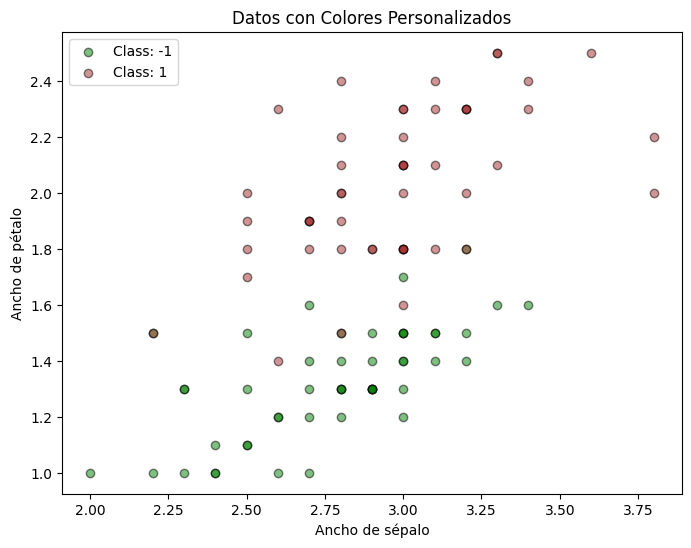

In [ ]:
plt.figure(figsize=(8, 6))
plot_data(X_noscale, y)
plt.show()

Los datos son arreglos bi-dimensionales de números. Cada fila corresponde a una
instancia/objeto de entrenamiento, sobre el cual queremos aprender o hacer una predicción
sobre sus datos.

In [ ]:
print("Forma de x:", X.shape)
print("Forma de y:", y.shape)
print("Conteo por clase:", np.unique(y, return_counts=True))

Forma de x: (100, 2)
Forma de y: (100,)
Conteo por clase: (array([-1,  1]), array([50, 50]))


In [ ]:
print(y)

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1]


**¿Cómo diferenciamos entre ambas clases de manera automática?**


---

La diferenciación se logra mediante un modelo de discriminación lineal que sigue estos tres pasos:
- **Línea divisoria:** El modelo utiliza una función matemática ($f(x) = wx + b$) que actúa como una frontera entre los grupos de datos.
- **Regla de decisión:** Al recibir un dato nuevo, el sistema calcula su valor en la función; si el resultado está por encima de un umbral ($\theta$), se clasifica en una categoría, y si está por debajo, en la otra.
- **Aprendizaje automático:** El proceso es "automático" porque el algoritmo ajusta por sí solo los valores de la línea ($w$ y $b$) para minimizar la función de pérdida.

Esto significa que el sistema busca la posición de la línea que cometa la menor cantidad de errores posible al comparar sus predicciones con los datos reales4.

**Clasificación con un modelo lineal**
### Discriminación Lineal

El modelo de clasificación es una función que recibe un ejemplo **x** y devuelve una predicción.
Este modelo usa una función llamada 'discriminate':  
$f: R^2 \rightarrow R$ tal que:  
$$Prediccion(x)=\begin{cases}C_{1}&si~f(x)\ge\theta\\ C_{2}&si~f(x)<\theta\end{cases}$$
Para la discriminación lineal, definimos $f$ (el descriminante) como un modelo lineal con parametros w y b:  
$$f(x) = wx + b$$

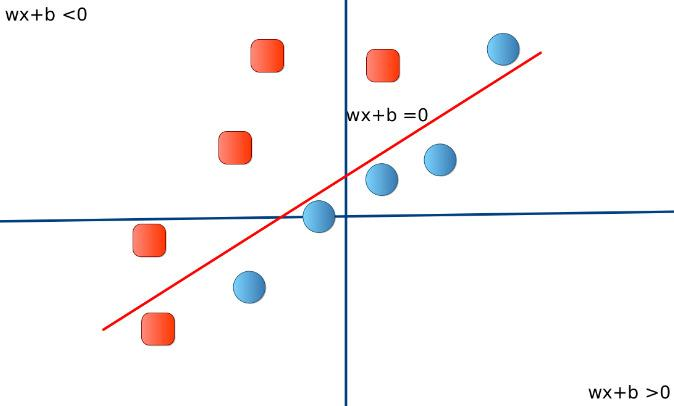

**¿Cómo encontrar $f$?**


---


Para encontrar la función $f$, se plantea como un problema de optimización1. El objetivo es seleccionar, dentro de un conjunto de funciones posibles (llamado espacio de hipótesis $H$), aquella que genere el error mínimo al compararla con todos los ejemplos del conjunto de datos.  
Matemáticamente, buscamos minimizar la pérdida total:
$$\min_{f \in H} L(f, D)$$

**¿Cómo estimamos $w$ y $b$?**


---


Estimamos estos parámetros mediante un proceso de ajuste
automático que busca reducir la "distancia" entre lo que el modelo predice y la realidad.  
- **Uso de la Función de Pérdida:** Se utiliza la pérdida cuadrática para medir qué tan mal se comporta el modelo con unos valores específicos de $w$ (pendiente) y $b$ (intercepto).
- **Algoritmo de Optimización:** Se emplea el Gradiente Descendente para automatizar la búsqueda. Este algoritmo modifica los valores de $w$ y $b$ paso a paso hasta llegar al punto donde la pérdida es la más baja posible.

### Aprendizaje como optimización
La función de pérdida nos ayuda a estimar qué tan mal se comporta una función f del espacio de hipótesis con respecto al conjunto de datos D.

In [ ]:
# Función de predicción
def predict(w, x):
  a = np.dot(w[1:], x) + w[0]
  return a

**Explicación de la función**


---

Esta función calcula la salida del modelo lineal (la "función discriminante").  
Realiza el producto punto entre los pesos de las características (w[1:]) y los datos de entrada x, sumando finalmente el término de sesgo o bias (w[0]).  
Su resultado es un valor numérico real; si es positivo, el modelo clasifica el objeto en una categoría, y si es negativo, en la otra.

In [ ]:
# Función de error cuadratico
def square_loss(w, x, y):
    return (y - predict(w, x))**2 / 2

**Explicación de la función**


---
Implementa la métrica de error para un solo ejemplo individual.  
Calcula la diferencia entre la etiqueta real y y la predicción generada por el modelo, eleva esa diferencia al cuadrado y la divide entre dos.  
Esto penaliza fuertemente las predicciones que están muy alejadas de la realidad, proporcionando un valor siempre positivo que queremos minimizar.

In [ ]:
# Función de error total
def batch_loss(loss_fun, w, X, Y):
  n =X.shape[0]
  tot_loss = 0
  for i in range(n):
    tot_loss += loss_fun(w, X[i], Y[i])
  return tot_loss

**Explicación de la función**


---
Esta es una función acumuladora que calcula el error total del modelo sobre todo el conjunto de datos.  
Itera a través de cada fila de la matriz *x*, calcula la pérdida individual usando `loss_fun` y suma todos estos valores para devolver la pérdida global.  
Es fundamental para evaluar qué tan bien se comporta un conjunto específico de parámetros w en todo el dataset.

In [ ]:
# Escojemos el primer ejemplo de nuestro conjunto de datos Iris
w = [1, 5, 2]
x = X[0]
label = y[0]

print(f'Caracteristicas: {X[0]}')
print(f'Etiqueta real: {y[0]}')
print(f'Función discriminante: {predict(w, x)}')

Caracteristicas: [ 0.99068792 -0.65303909]
Etiqueta real: -1
Función discriminante: 4.647361438018154


In [ ]:
print(f'Perdida: {square_loss(w, x, label)}')

Perdida: 15.946345605807238


**¿Qué pasa si modificados uno de los parámetros w?**

In [ ]:
w_p = [1, 5, 3]

In [ ]:
print(f'Etiqueta: {y[0]}')
print(f'Predicción: {predict(w_p, x)}')
print(f'Pérdida: {square_loss(w_p, x, label)}')

Etiqueta: -1
Predicción: 3.9943223502437437
Pérdida: 12.471627869072096


In [ ]:
# Funciones para visualizar la función de perdida
def plot_loss(loss):
  w1_vals = np.linspace(-5, 5, 30)
  w2_vals = np.linspace(-5, 5, 30)
  W1, W2 = np.meshgrid(w1_vals, w2_vals)
  grid_r, grid_c = W1.shape
  ZZ = np.zeros((grid_r, grid_c))
  for i in range(grid_r):
    for j in range(grid_c):
      ZZ[i, j] = loss(W1[i, j], W2[i, j])
  plt.contourf(W1, W2, ZZ, 30, cmap = plt.cm.jet)
  plt.colorbar()
  plt.xlabel("$w_1$")
  plt.xlabel("$w_2$")

In [ ]:
def bloss_square(w1, w2):
  w = np.array([1, w1, w2])
  return batch_loss(square_loss, w, X, y)

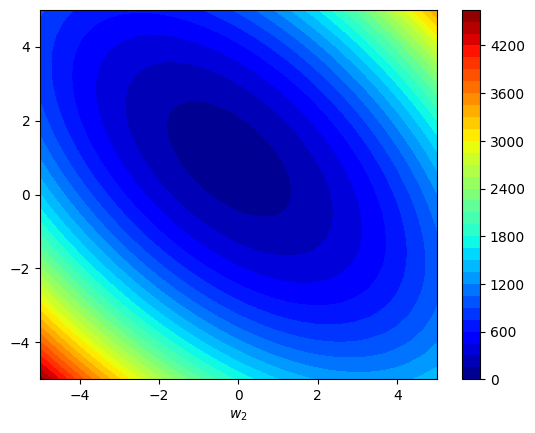

In [ ]:
plot_loss(bloss_square)

##Parte 2

### Gradiente Descendiente

Algoritmo gradiente descendente:  
- Paso 1: Escogemos un valor inicial o punto de partida. Puede ser cero o un valor aleatorio. Este valor inicial no tiene relevancia para este problema.  
- Paso 2: Calculamos el gradiente de la función de pérdida gradiente para el punto de partida. El gradiente a su vez me indica la derivada (inclinación) de la curva. El gradiente a su vez es un vector, por lo tanto, tiene dirección y magnitud, esta dirección siempre apunta hacia donde se genera el mayor incremento en la función de pérdida.  
- Paso 3: Calculamos un nuevo valor w cambiándolo en la dirección negativa del gradiente, con el objetivo reducir la pérdida lo más pronto posible.  
- Paso 4: El nuevo valor de w también estará determinado por la magnitud del
gradiente y una taza de aprendizaje taza de aprendizaje taza de aprendizaje η.

**¿Qué pasa si el tamaño de nuestro paso es muy grande?**


---


Si la tasa de aprendizaje ($\eta$) es muy alta, el algoritmo puede "saltar" sobre el punto mínimo y nunca alcanzar la convergencia, provocando que la pérdida oscile o incluso aumente. Por el contrario, si es muy pequeña, el proceso será extremadamente lento para llegar al mínimo global.

In [ ]:
def de_dw(w, x, r):
    """Calcula las derivadas parciales de E con respecto a w"""
    x_prime = np.zeros(len(x) + 1)
    x_prime[1:] = x
    x_prime[0] = 1 # Término para el intercepto w0
    return (predict(w, x) - r) * x_prime # Derivada del error cuadrático

### Gradiente descendente en batch
Para estimar el gradiente, lo hacemos a lo largo de todo nuestro conjunto de datos.  
Puesto que solo contamos con 100 ejemplos, es relativamente rápido hacer este cálculo. Sin embargo, en la práctica puede ser ineficiente si se cuenta con un gran número de ejemplos de entrenamiento.

In [ ]:
def batch_gd(X, Y, epochs, eta, w_ini):
    """Estima el gradiente a lo largo de todo el conjunto de datos

    X: instancias del conjunto de datos
    Y: etiquetas del conjunto de datos
    epochs: núero de iteraciones para ejecutar gradiente descendente
    eta: taza de aprendizaje
    w_ini: w y w_0 iniciales
    """
    losses = []
    w = w_ini
    n = X.shape[0]
    for i in range(epochs):
        delta = np.zeros(len(w))
        for j in range(n):
            # Sumamos el gradiente por cada ejemplo
            delta += de_dw(w, X[j], Y[j])
        # Actualizamos w en dirección negativa del gradiente
        w = w - eta * delta
        losses.append(batch_loss(square_loss, w, X, Y))
    return w, losses

Vamos a ejecutar gradiente descendente en batch con los siguientes parámetros:  
- epochs = 50  
- w0 = 0 (w0 inicial)  
- w = [0,0] (w inicial)  
- η = 0.01 (tasa de aprendizaje)

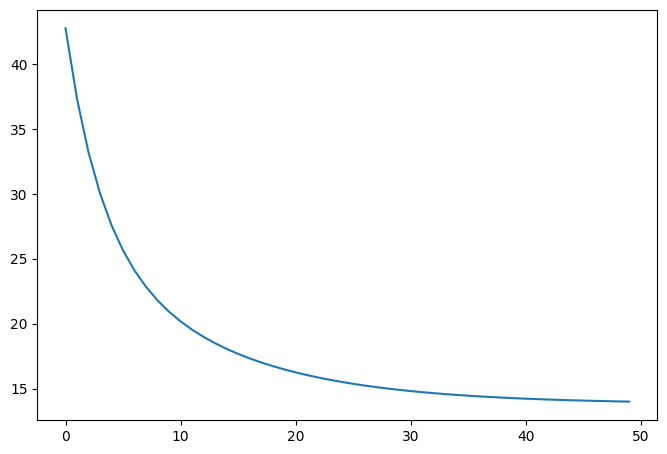

In [ ]:
w, losses = batch_gd(X, y, 50, 0.001, np.array([0, 0, 0]))
plt.figure(figsize = (8,16/3))
plt.plot(losses)
plt.show()

### Gradiente descendente estocástico (SGD)
Cuando trabajamos con grandes conjuntos de datos, se vuelve poco práctico el cálculo del gradiente sobre todo el conjunto de datos. Una forma de disminuir el tiempo de computación es escogiendo muestras al azar de nuestro conjunto de datos, que nos generan un estimado en promedio del gradiente promedio.  
SGD toma entonces una muestra de forma aleatoria a la vez y estima el valor del gradiente para esa muestra. A pesar de ser ruidoso, SGD funciona bastante bien en la práctica.

In [ ]:
def sgd(X, Y, epochs, eta, w_ini):
    """Estima el gradiente usando muestras al azar una a la vez

        X: instancias del conjunto de datos
        Y: etiquetas del conjunto de datos
        epochs: núero de iteraciones para ejecutar gradiente descendente
        eta: taza de aprendizaje
        w_ini: w y w_0 iniciales
    """
    losses = []
    w = w_ini
    n = X.shape[0]
    index = list(range(n))
    for i in range(epochs):
        np.random.shuffle(index) # Mezcla aleatoria de datos
        for j in index:
            # Estimamos gradiente para un solo elemento
            delta = de_dw(w, X[j], Y[j])
            w = w - eta * delta
        losses.append(batch_loss(square_loss, w, X, Y))
    return w, losses

In [ ]:
# Ejemplo de orden aleatorio
index = list(range(10))
print(index)
np.random.shuffle(index)
print(index)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 7, 9, 2, 3, 4, 1, 6, 8, 5]


A continuación, comparamos el comportamiento de Gradiente Descendente en Batch y Estocástico. Observamos que tienen un comportamiento similar para nuestro problema de clasificación de dos clases.

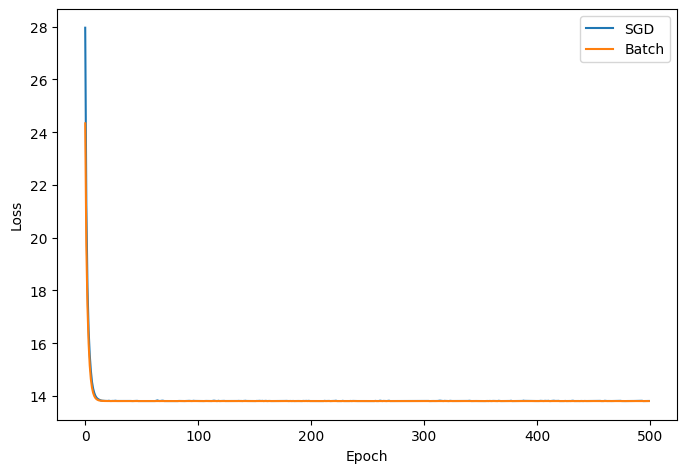

In [ ]:
# Ejecución y gráfica final
lr = 0.005
epochs = 500
w1, losses_bt = batch_gd(X, y, epochs, lr, np.array([0, 0, 0])) #Batch
w2, losses_ol = sgd(X, y, epochs, lr, np.array([0, 0, 0])) #SGD
plt.figure(figsize = (8,16/3))
plt.plot(np.arange(epochs), losses_ol, label="SGD")
plt.plot(np.arange(epochs), losses_bt, label="Batch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Visualiza regiones asignadas a clase positiva y negativa
def plot_decision_region(X, pred_fun):
  """
  X: corresponde a las instancias del conjunto de datos
  pred_fun: es una funcion que para cada valor de X, regresa una prediccion
  """
  min_x = np.min(X[:, 0])
  max_x = np.max(X[:, 0])
  min_y = np.min(X[:, 1])
  max_y = np.max(X[ :, 1])

  min_x = min_x - (max_x - min_x) * 0.05
  max_x = max_x + (max_x - min_x) * 0.05
  min_y = min_y - (max_y - min_y) * 0.05
  max_y = max_y + (max_y - min_y) * 0.05

  x_vals = np.linspace(min_x, max_x, 30)
  y_vals = np.linspace(min_y, max_y, 30)

  XX, YY = np.meshgrid(x_vals, y_vals)
  grid_r, grid_c = XX.shape
  ZZ = np.zeros((grid_r, grid_c))

  for i in range(grid_r):
    for j in range(grid_c):
      ZZ[i, j] = pred_fun(XX[i, j], YY[i, j])

  plt.contourf(XX, YY, ZZ, 30, cmap = plt.cm.coolwarm, vmin= -1, vmax=2)
  plt.colorbar()
  plt.xlabel("x")
  plt.ylabel("y")

In [ ]:
def gen_pred_fun(w):
  def pred_fun(x1,x2):
    x = np.array([x1, x2])
    return predict(w, x)
  return pred_fun

Visualicemos el caso donde nuestros coeficientes sean de la forma:  
- w0 = 0  
- w = [0.6,1]

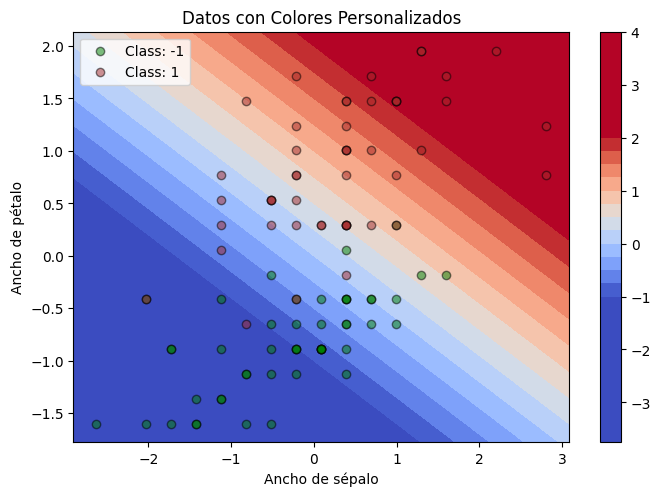

In [ ]:
w = [0, 0.6, 1]

plt.figure(figsize = (8,16/3))
plot_decision_region(X, gen_pred_fun(w))
plot_data(X, y)

Visualizamos el resultado luego de aplicar SGD:

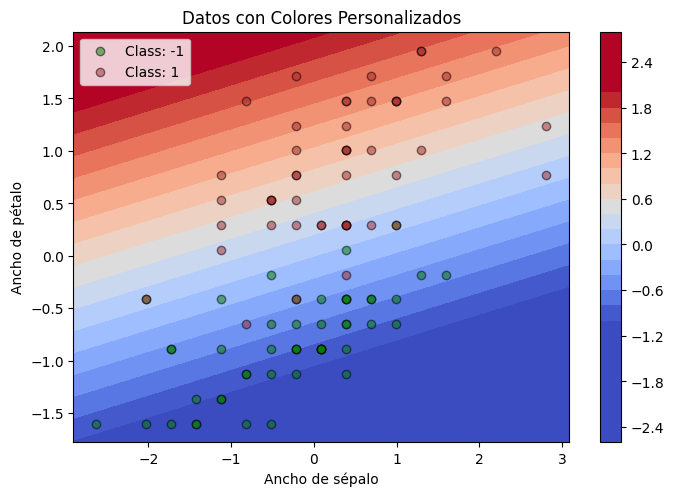

In [ ]:
lr = 0.005
epochs = 500
w, _= sgd(X, y, epochs, lr, np.array([0, -1, 2])) #SGD

plt.figure(figsize = (8,16/3))
plot_decision_region(X, gen_pred_fun(w))
plot_data(X, y)

Para obtener la última gráfica, se somete el modelo a un proceso iterativo de Gradiente Descendente Estocástico (SGD) durante 500 épocas. En cada iteración, el algoritmo toma los puntos de datos en un orden aleatorio para estimar el gradiente del error. Este proceso ajusta los pesos $w$ y el sesgo $b$ moviéndolos en la dirección opuesta al gradiente para reducir la pérdida. El resultado visual es un mapa de calor donde la transición de colores (del azul al rojo) representa la "frontera de decisión"; los puntos de una clase quedan en la zona azul y los de la otra en la roja, demostrando que el modelo ha aprendido a separar las categorías automáticamente.

In [ ]:
print("Valores finales de w:", w)

Valores finales de w: [ 0.00428235 -0.23484107  0.95954997]


**CONCLUSIÓN**


---

A través de esta práctica, se comprobó que el Gradiente Descendente es un mecanismo iterativo eficaz para hallar el valor de convergencia de una función de pérdida convexa. Se observó que, mientras el método en Batch es estable al usar todo el conjunto de datos, el Gradiente Descendente Estocástico (SGD) ofrece una alternativa más eficiente para problemas de gran escala, logrando resultados similares a pesar de la naturaleza ruidosa de sus actualizaciones. Finalmente, la visualización de las regiones de decisión nos permitió validar que la minimización de la pérdida cuadrática conduce efectivamente a una clasificación lineal correcta entre las categorías de flores analizadas.